### 2_1 - Train based only geometric

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k.csv')

x = data.drop(columns=['query' , 'Unnamed: 0'])

In [2]:
x.head(3)

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
0,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665
1,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665
2,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665


#### Kmeans

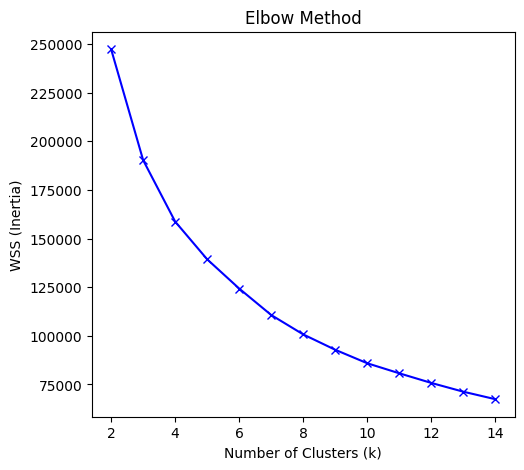

In [ ]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [34]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

#first 5 to 10 increas+
for k in range(250, 300, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

# as we add more k it gives best score but it s over clustring some clusters get 1

2 0.5289418165829582
3 0.36523307008226374
4 0.36756940884838124
5 0.3497787108894109
6 0.3390675055179179
7 0.35552008922394
8 0.34657434530688913
9 0.3361303493212771
250 0.8038699577214768
260 0.8075741752071995
270 0.8162742586447713
280 0.8190470514344496
290 0.8238863856265176


In [ ]:
#Kmeans Model  2 k

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

for i in range(2):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(6).values)

# it gives simple geometric clusters , 
# cluster 0 :  direct query no specifics or no number
# cluster 1 : querie with number or specifics 

kmeans_cluster
0    42016
1     7984
Name: count, dtype: int64

--- Examples of Cluster 0 ---
<StringArray>
[            'workout weights',         'nintendo gift cards',
               'urban skin rx',                   'bird seed',
 '+foot cream without alcohol',                'cpap filters']
Length: 6, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[  'brother tn730 high yield black toner',
                              '60 lashes',
                          'iphone used 6',
                  'compost bags 3 gallon',
 '06 suzuki 600 side fairing not painted',
                          'ffp2 not kn95']
Length: 6, dtype: str


In [ ]:
#Kmeans Model  6 k

kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
0    16374
4    15658
1    10218
3     6015
2     1633
5      102
Name: count, dtype: int64


In [38]:
for i in range(6):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(4).values)


--- Examples of Cluster 0 ---
<StringArray>
[               '+foot cream without alcohol',
              'long cord lavalier microphone',
 'hyundai accent steering wheel sign sticker',
                 'bronze toilet paper holder']
Length: 4, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[        'workout weights', 'tumblers bulk wholesale',
         'lebel cosmetics', 'smartphone tripod mount']
Length: 4, dtype: str

--- Examples of Cluster 2 ---
<StringArray>
[                       'hose reel 1/4',
       ''oh no not you again' door mat',
                             'pma ep-2',
 '.8 beading wire plastic not stretchy']
Length: 4, dtype: str

--- Examples of Cluster 3 ---
<StringArray>
['brother tn730 high yield black toner',
                            '60 lashes',
                        'iphone used 6',
                'compost bags 3 gallon']
Length: 4, dtype: str

--- Examples of Cluster 4 ---
<StringArray>
['nintendo gift cards', 'urban skin rx', 'bird seed', 'cpap f

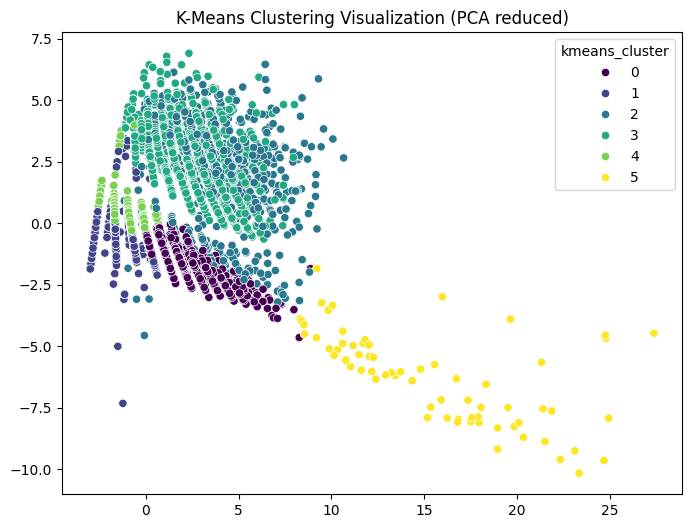

In [39]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['kmeans_cluster'], palette='viridis')
plt.title('K-Means Clustering Visualization (PCA reduced)')
plt.show()

#### GMM

In [11]:
from sklearn.mixture import GaussianMixture

#gmm model
gmm = GaussianMixture(n_components=6, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x)


for i in range(6):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(5).values)


--- GMM Cluster 0 ---
<StringArray>
[                          '+foot cream without alcohol',
                                   'women's dress socks',
                        ''oh no not you again' door mat',
 'retirement t shirts for women that say not my problem',
                          'm.graham watercolor paints s']
Length: 5, dtype: str

--- GMM Cluster 1 ---
<StringArray>
[    'workout weights', 'nintendo gift cards',       'urban skin rx',
           'bird seed',        'cpap filters']
Length: 5, dtype: str

--- GMM Cluster 2 ---
<StringArray>
[                                                                                                                         'jewellery+box+small+crystal',
 'ideally something with 8gb of ram, probably a windows laptop around £400 as in my experience that's what you can rely on and macs are too expensive.',
                  'Good size keyboard, large screen, detachable keyboard so it can be used as a tablet.  Decent camera and webcam.  

In [42]:
# probability 
probs = gmm.predict_proba(x)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights            1        1.000000
1                   nintendo gift cards            1        0.860696
2                         urban skin rx            1        0.996781
3                             bird seed            1        0.999999
4           +foot cream without alcohol            0        1.000000
5  brother tn730 high yield black toner            5        1.000000
6                             60 lashes            5        1.000000
7                          cpap filters            1        0.963931
8         long cord lavalier microphone            4        0.989382
9               tumblers bulk wholesale            1        0.999863


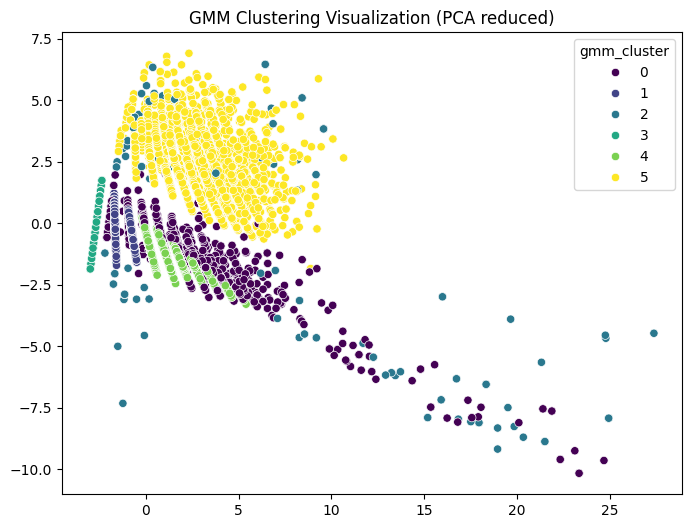

In [43]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['gmm_cluster'], palette='viridis')
plt.title('GMM Clustering Visualization (PCA reduced)')
plt.show()

#### DBscan

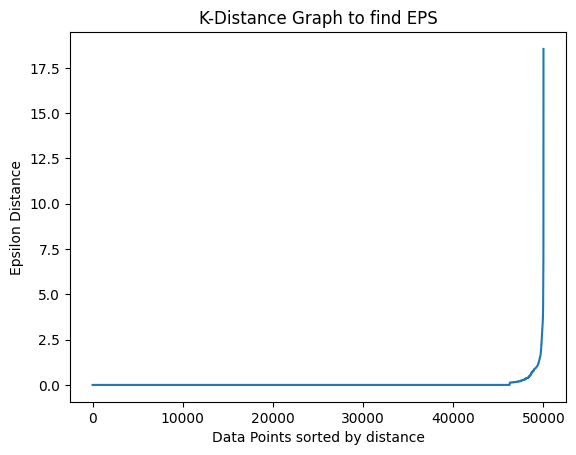

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np


#to choose e parameter eps
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

#  distances
distances = np.sort(distances[:, 9], axis=0)

plt.plot(distances)
plt.title('K-Distance Graph to find EPS')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon Distance')
plt.show()

#somthing smaller 0.5 1.5 ..

In [12]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,min_samples=10 , metric='euclidean'
)

labels = dbscan.fit_predict(x)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
 0     41295
 4      2650
 3      2143
 1       885
 2       875
 6       597
-1       399
 10      341
 11      228
 8       169
 7       136
 5        94
 13       58
 12       36
 15       19
 16       16
 9        15
 14       12
 18       12
 19       10
 17       10
Name: count, dtype: int64

 Cluster -1
['jewellery+box+small+crystal', "b'haystacks pennsylvania'", '1/2 in air hose reel 100 ft retractable without hose', 'I would just like to have a jacket with pockets, and is light and plain looking; no flashy colors.', 'The jacket I am planning on buying is a hoodie with high visibility reflective strips on it, for safety.']

 Cluster 0
['workout weights', 'nintendo gift cards', 'urban skin rx', 'bird seed', 'cpap filters']

 Cluster 1
['+foot cream without alcohol', "women's dress socks", 'm.graham watercolor paints s', "men's armour fleece pants", 'bb-gun rifle']

 Cluster 2
['brother tn730 high yield black toner', 'ffp2 not kn95', 'rear rack duke 390', 'bat181', 'f2

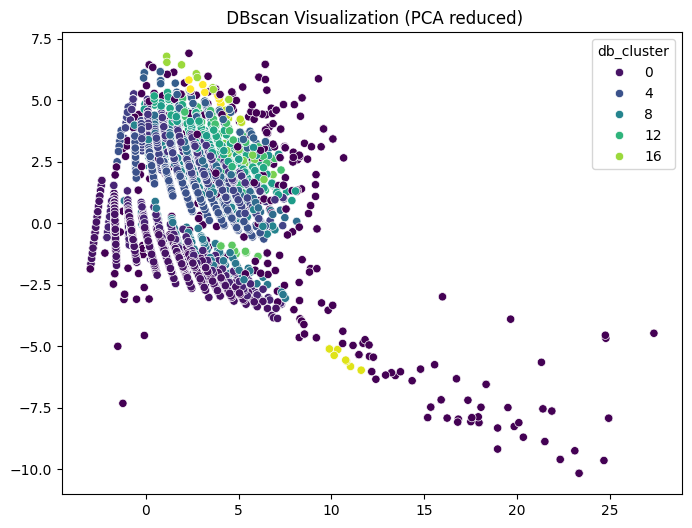

In [54]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['db_cluster'], palette='viridis')
plt.title(' DBscan Visualization (PCA reduced)')
plt.show()

### hdbscan

In [13]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=7,   
    min_samples=10,        
    metric='euclidean'
)

labels_hdb = clusterer.fit_predict(x)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
-1      1513
 3      1450
 2      1426
 169    1386
 167    1317
        ... 
 403       8
 140       7
 211       7
 409       7
 191       7
Name: count, Length: 448, dtype: int64

 HDBscan Cluster -1 ---
['jewellery+box+small+crystal', 'pma ep-2', 'usb c fast charge 3ft v2', 'best toys for 1 year old boy', 'care and keeping of you book 1']

 HDBscan Cluster 0 ---
['I want a long jacket that comes to mid leg in a dark colour and very warm', 'I would choose a blue hoodie as a replacement jacket that i would want to buy', 'I want a Kenneth Cole peacoat that is double padded on the inside and has minimal buttons', 'I want a long jacket that comes to mid leg in a dark colour and very warm', 'I would choose a blue hoodie as a replacement jacket that i would want to buy']

 HDBscan Cluster 1 ---
['bottle glass lamp', 'wood match sticks', 'opti filter water', 'primo bottom load', 'kopi luwak coffee']

 HDBscan Cluster 2 ---
['nintendo gift cards', 'minnie womens shirt', 'car

### evaluating

In [14]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [15]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
X_sample = x.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.355443       18164.499198        1.011555           6
1      gmm    0.325777       11312.999511        1.737132           6
2   dbscan    0.423010        2269.903407        1.760141          20
3  hdbscan    0.951633        7055.474307        0.521733         447
